In [ ]:
# ── repo path bootstrap ───────────────────────────────────────────────────────
# REORGANISATION_FIX_PLAN.md 5.8.  The modules are flat but live in
# Transformer_model/ and Experimental_setup/, and this notebook sits in
# Jupyter_notebooks/, so the cwd alone is not enough.  Walk up to the .git marker,
# chdir there so repo-relative data paths resolve as they did before the tree was
# reorganised, and put both source directories on sys.path.
# Idempotent -- safe to re-run this cell.
import os, sys
_p = os.path.abspath(os.getcwd())
while not os.path.isdir(os.path.join(_p, ".git")) and _p != os.path.dirname(_p):
    _p = os.path.dirname(_p)
ROOT = _p
os.chdir(ROOT)
for _d in ("Transformer_model", "Experimental_setup"):
    if os.path.join(ROOT, _d) not in sys.path:
        sys.path.insert(0, os.path.join(ROOT, _d))
print("repo root:", ROOT)


# Sequence Prediction Analysis
Load trained forward and backward models, then visualise how each model predicts token-by-token from an initial token.

**Forward model**: predicts x_{t+1} given x_{0..t} — context grows rightward  
**Backward model**: predicts x_{t-1} given x_{t..T} — context grows leftward

In [10]:
%matplotlib inline
from IPython.display import display

import torch
import torch.nn.functional as F
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec

from OneHot_model import OneHotDecoder

print('Imports OK')

Imports OK


## Config — edit to match your trained model

In [25]:
# ── Architecture — must match training CFG ────────────────────────────────
D_MODEL    = 64
MAX_LEN    = 2000
N_LAYERS   = 2
NUM_TOKEN  = 3      # coin=3, flower n=6 m=4 → 10

# ── Experiment to load ───────────────────────────────────────────────────
RESULTS_DIR = 'results'
EXP_TAG     = 'exp1_2_coin_p04_q08'

FW_WEIGHTS  = f'{RESULTS_DIR}/models/{EXP_TAG}_fw.pt'
BW_WEIGHTS  = f'{RESULTS_DIR}/models/{EXP_TAG}_bw.pt'

# ── Generation settings ──────────────────────────────────────────────────
START_TOKEN = 1      # token the model starts from
GEN_LEN     = 2000    # number of steps to generate
N_RUNS      = 5     # independent generation runs to show variance

# token labels for coin process
TOKEN_LABELS = {0: '0 (T→T)', 1: '1 (→H)', 2: '2 (H→T)'}
# for flower: {i: f'die {i}' for i in range(n)} | {n+j: f'face {j}' for j in range(m)}

## Load Models

In [26]:
def load_model(path, mode):
    model = OneHotDecoder(
        token_size=NUM_TOKEN, d_model=D_MODEL,
        max_len=MAX_LEN, mode=mode, n_layers=N_LAYERS)
    model.load_state_dict(torch.load(path, map_location='cpu'))
    model.eval()
    print(f'  loaded {path}  [{mode}]')
    return model

model_fw = load_model(FW_WEIGHTS, 'forward')
model_bw = load_model(BW_WEIGHTS, 'backward')

  loaded results/models/exp1_2_coin_p04_q08_fw.pt  [forward]
  loaded results/models/exp1_2_coin_p04_q08_bw.pt  [backward]


## Core generation functions

In [27]:
def get_probs(model, context):
    """
    Run model on context and return the prediction probabilities.
    Forward : reads logits at last position  (max past context)
    Backward: reads logits at first position (max future context)
    """
    is_bw = (model.mode == 'backward')
    x = torch.tensor([context])           # (1, T)
    with torch.no_grad():
        logits = model(x)                 # (1, T, V)
    logits = logits[:, 0, :] if is_bw else logits[:, -1, :]  # (1, V)
    probs  = torch.softmax(logits[0], dim=-1).numpy()         # (V,)
    return probs


def generate_sequence(model, start_token, gen_len, burn_in=200):
    is_bw     = (model.mode == 'backward')
    context   = [start_token]
    sequence  = []
    prob_hist = []
    chosen    = []

    with torch.no_grad():
        for i in range(gen_len + burn_in):
            probs      = get_probs(model, context)
            next_token = int(np.random.choice(NUM_TOKEN, p=probs))

            # only record after burn-in
            if i >= burn_in:
                prob_hist.append(probs)
                chosen.append(next_token)
                sequence.append(next_token)

            if is_bw:
                context = [next_token] + context   # grow leftward
            else:
                context = context + [next_token]   # grow rightward

    # all three lists are now exactly gen_len long and aligned
    return sequence, prob_hist, chosen


print('Functions defined')

Functions defined


## 1 — Single generation trace
Show the full token sequence and the model's predicted distribution at each step.

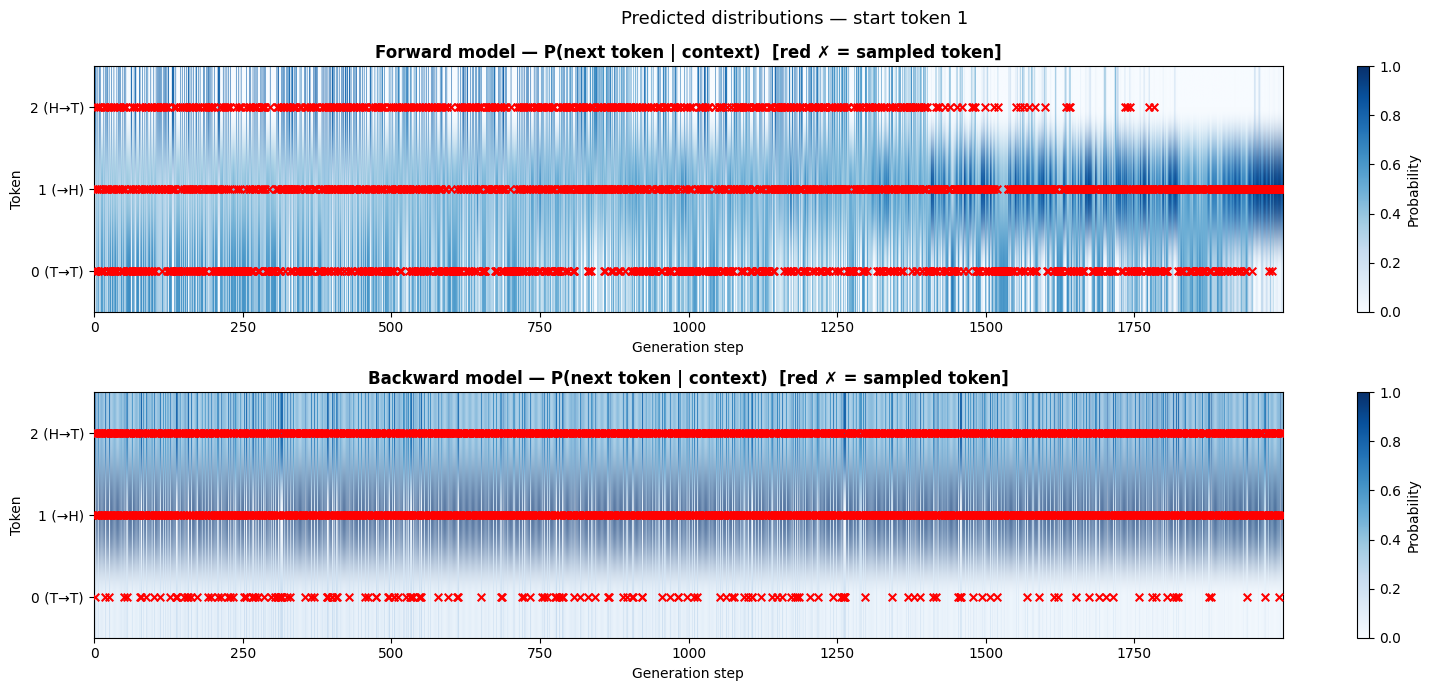

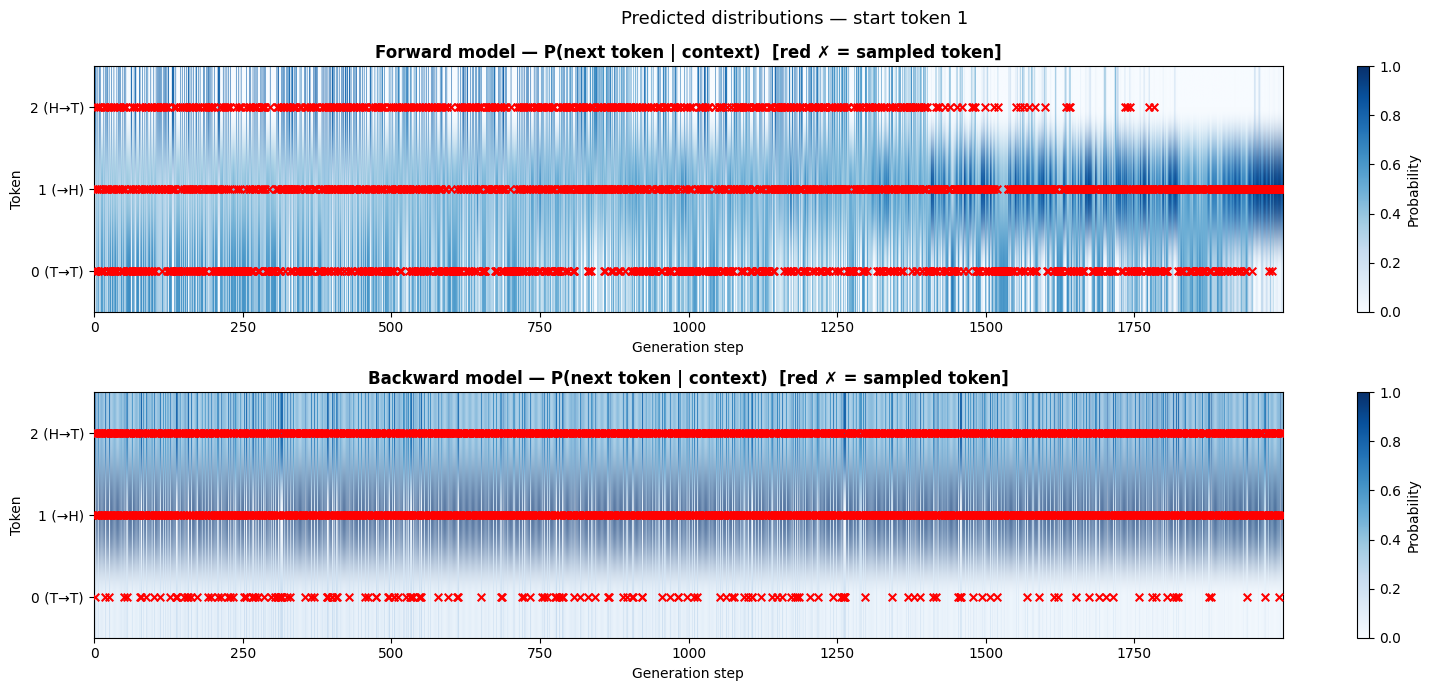

In [28]:
seq_fw, ph_fw, ch_fw = generate_sequence(model_fw, START_TOKEN, GEN_LEN)
seq_bw, ph_bw, ch_bw = generate_sequence(model_bw, START_TOKEN, GEN_LEN)

fig, axes = plt.subplots(2, 1, figsize=(16, 7), sharex=False)

for ax, ph, ch, lbl in zip(axes, [ph_fw, ph_bw], [ch_fw, ch_bw],
                            ['Forward model', 'Backward model']):
    # heatmap of predicted probability distribution over steps
    mat = np.array(ph).T                          # (V, GEN_LEN)
    im  = ax.imshow(mat, aspect='auto', origin='lower',
                    cmap='Blues', vmin=0, vmax=1)
    # mark the chosen token at each step
    for t, tok in enumerate(ch):
        ax.scatter(t, tok, color='red', s=30, zorder=5, marker='x')
    ax.set_yticks(range(NUM_TOKEN))
    ax.set_yticklabels([TOKEN_LABELS.get(i, str(i)) for i in range(NUM_TOKEN)])
    ax.set_xlabel('Generation step')
    ax.set_ylabel('Token')
    ax.set_title(f'{lbl} — P(next token | context)  [red ✗ = sampled token]',
                 fontweight='bold')
    plt.colorbar(im, ax=ax, label='Probability')

plt.suptitle(f'Predicted distributions — start token {START_TOKEN}', fontsize=13)
plt.tight_layout()
display(fig)

## 2 — Generated token sequences (raw)
Print the actual token sequences produced by each model.

In [29]:
print(f'Start token: {START_TOKEN}')
print()
print(f'Forward  sequence ({GEN_LEN} tokens):')
print(' '.join(str(t) for t in seq_fw))
print()
print(f'Backward sequence ({GEN_LEN} tokens):')
print(' '.join(str(t) for t in seq_bw))
print()
# token frequency
for lbl, seq in [('Forward', seq_fw), ('Backward', seq_bw)]:
    counts = np.bincount(seq, minlength=NUM_TOKEN)
    freqs  = counts / len(seq)
    freq_str = '  '.join(f'tok{i}={freqs[i]:.3f}' for i in range(NUM_TOKEN))
    print(f'{lbl} token frequencies:  {freq_str}')

Start token: 1

Forward  sequence (2000 tokens):
0 1 1 2 0 1 2 0 1 1 2 0 0 0 0 1 2 0 1 2 1 1 2 0 1 2 0 0 1 2 0 0 1 2 0 0 0 1 2 0 1 1 2 1 2 0 0 1 2 0 1 2 1 2 0 0 0 0 0 0 0 1 1 2 0 0 1 2 1 1 2 0 0 0 0 1 1 2 0 0 1 2 0 0 1 2 0 1 2 1 2 0 0 0 1 2 0 0 0 1 2 0 0 1 2 1 2 1 2 1 1 2 1 2 0 1 2 1 2 1 1 2 0 1 1 2 0 0 0 0 1 1 1 1 2 0 1 2 0 0 0 0 0 0 1 2 0 1 2 0 0 1 2 0 1 2 0 1 1 2 1 2 0 1 2 0 1 2 0 0 1 1 2 0 1 2 0 1 2 0 0 0 0 1 1 2 0 0 1 2 1 1 2 1 2 1 2 1 2 0 0 1 2 0 0 0 0 1 1 1 1 2 0 0 0 0 1 2 0 1 2 0 1 2 0 1 2 0 1 2 0 0 0 0 0 0 0 0 1 2 0 0 1 2 0 0 1 2 0 0 0 0 0 0 0 1 2 0 0 0 1 2 1 2 0 0 1 2 0 1 2 1 2 1 2 0 0 0 0 1 2 1 2 1 2 1 2 1 2 0 0 0 0 0 0 1 2 0 0 0 0 0 0 0 0 0 1 2 1 1 2 0 0 0 1 2 1 1 2 1 2 0 1 2 1 2 1 1 1 2 0 1 1 1 2 0 1 2 1 1 2 0 0 0 0 1 2 1 2 0 0 0 0 1 1 2 0 1 2 0 0 1 1 2 0 0 0 0 1 2 1 1 2 1 1 2 0 0 0 0 0 0 1 2 1 2 0 1 2 1 2 0 1 2 0 1 1 2 0 1 1 1 2 1 2 0 1 2 1 2 0 1 2 0 0 1 2 1 1 2 0 1 1 2 1 1 2 0 1 1 2 1 2 0 0 1 2 1 2 1 1 2 0 0 0 1 2 1 2 0 1 2 0 1 2 0 0 1 2 0 0 0 0 1 1 2 1 2 0 0 0 1 2 0 0 1

In [30]:
def theory_freq(p, q):
    token1 = p/(p+q)
    token0 = (1-p)*q/(p+q)
    token2 = p*q/(p+q)
    return token0, token1, token2
fre0 , freq1, freq2 = theory_freq(0.3, 0.4)
print(f"freq0: {fre0}, freq1: {freq1}, freq2: {freq2}")


freq0: 0.39999999999999997, freq1: 0.4285714285714286, freq2: 0.17142857142857143


## 3 — Predicted probability at each step (line plot)
Show how confident each model is as context grows.

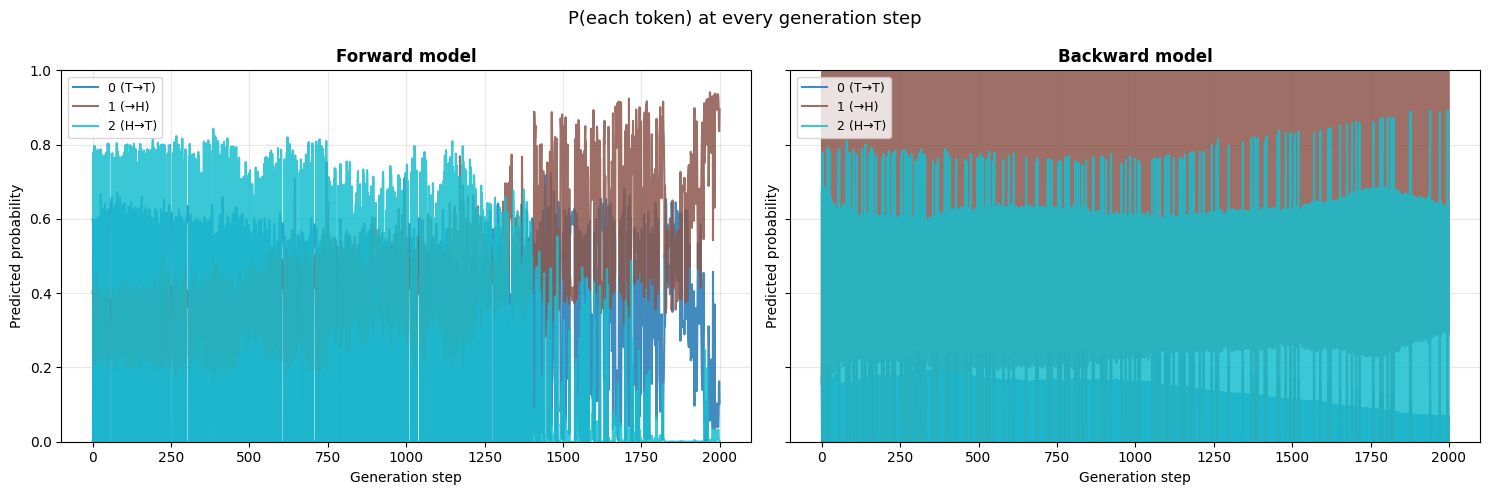

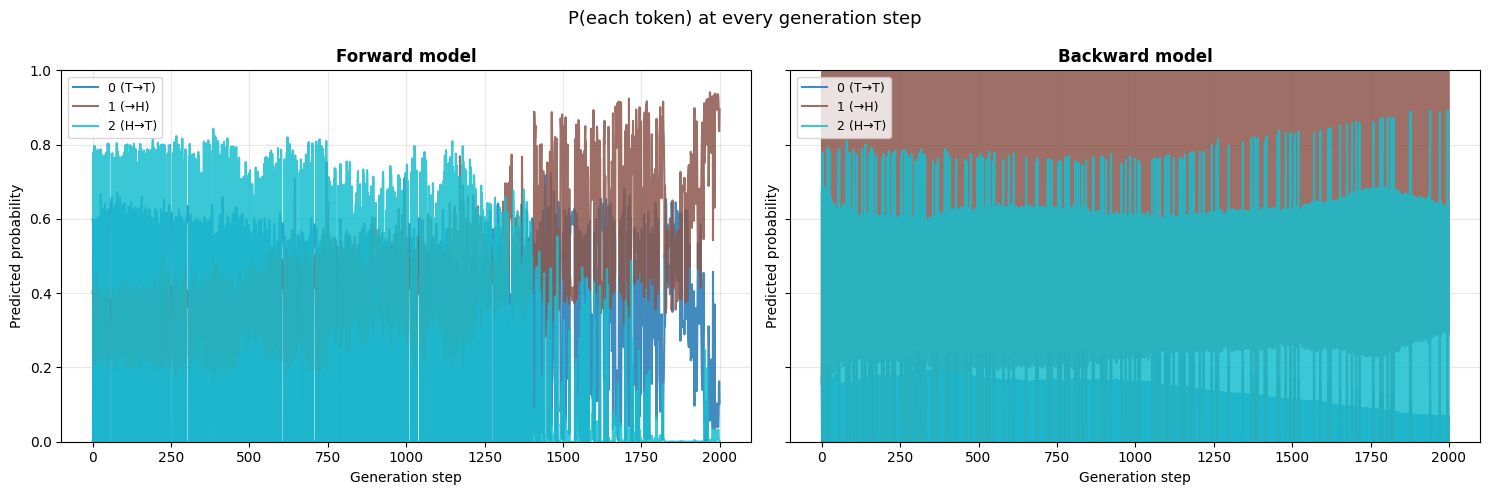

In [31]:
steps = np.arange(GEN_LEN)
cmap  = plt.cm.tab10

fig, axes = plt.subplots(1, 2, figsize=(15, 5), sharey=True)

for ax, ph, lbl in zip(axes, [ph_fw, ph_bw],
                        ['Forward model', 'Backward model']):
    for tok in range(NUM_TOKEN):
        p_tok = [ph[t][tok] for t in range(GEN_LEN)]
        ax.plot(steps, p_tok, lw=1.5, alpha=0.85,
                c=cmap(tok / max(NUM_TOKEN - 1, 1)),
                label=TOKEN_LABELS.get(tok, f'Token {tok}'))
    ax.set_xlabel('Generation step')
    ax.set_ylabel('Predicted probability')
    ax.set_title(lbl, fontweight='bold')
    ax.legend(fontsize=9)
    ax.grid(True, alpha=0.3)
    ax.set_ylim(0, 1)

plt.suptitle('P(each token) at every generation step', fontsize=13)
plt.tight_layout()
display(fig)

## 4 — Multiple runs: variance across independent generations
Run N_RUNS independent sequences to show the model's stochasticity.

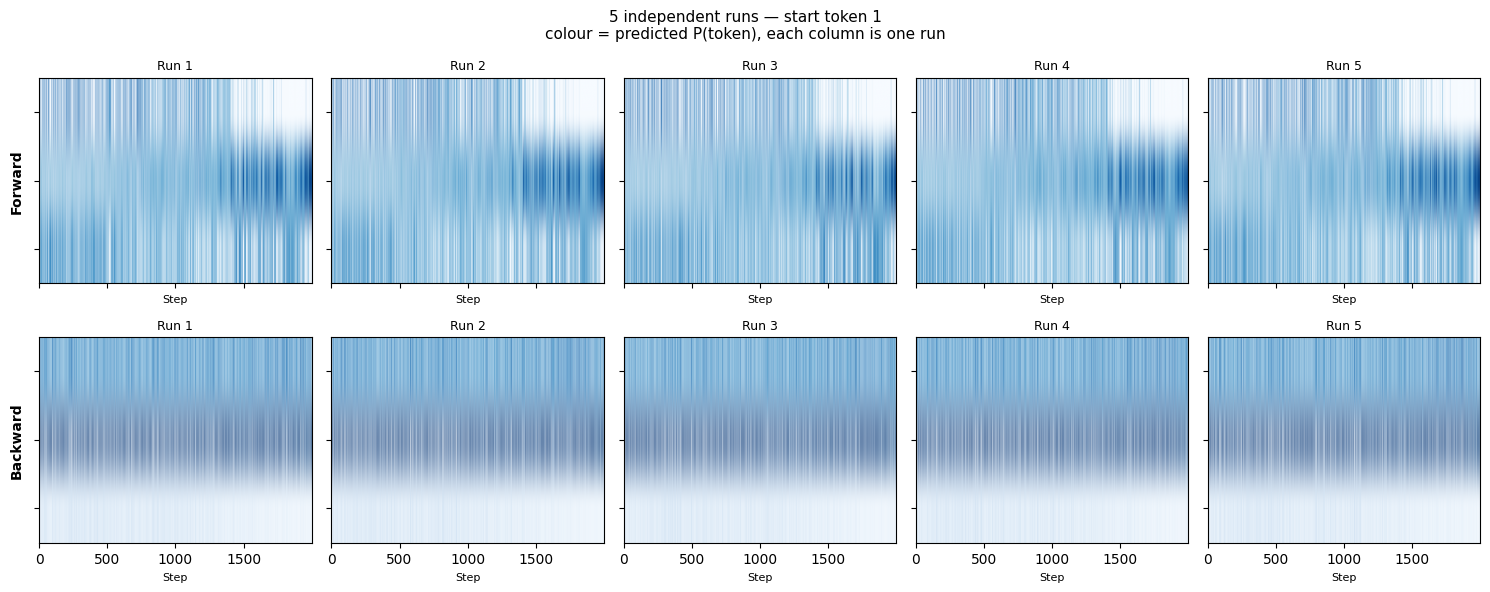

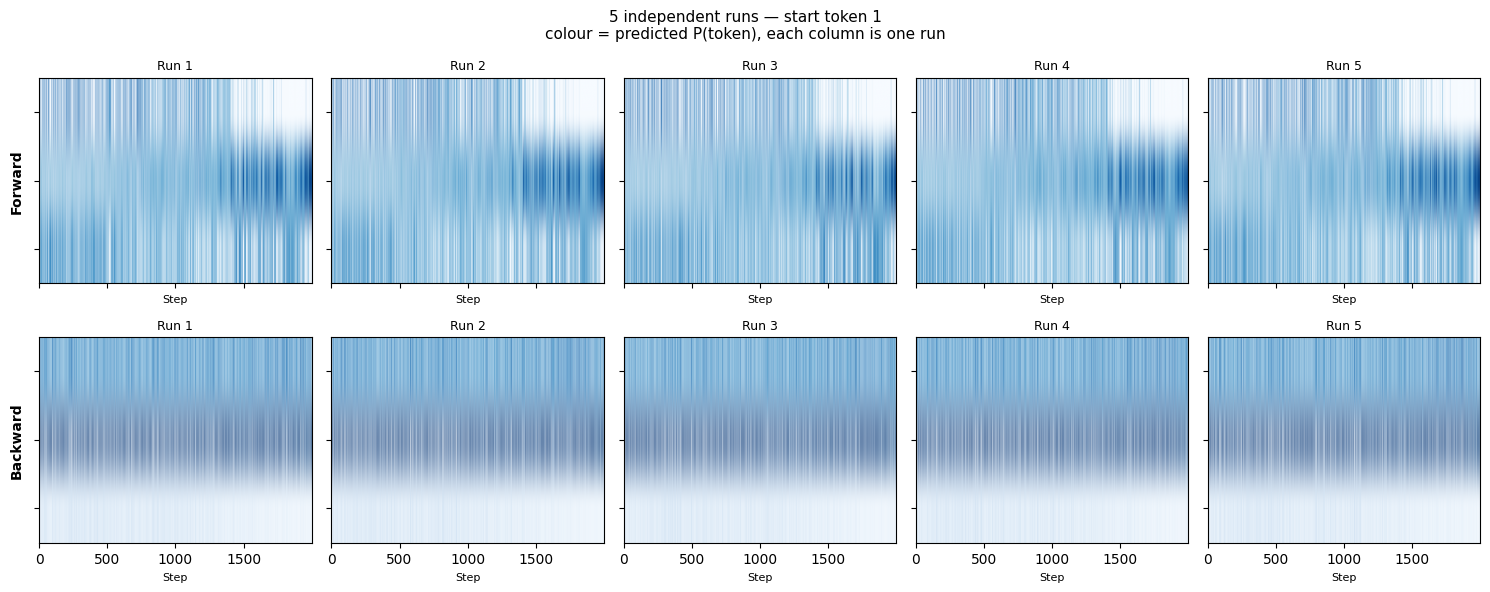

In [32]:
fig, axes = plt.subplots(2, N_RUNS, figsize=(3 * N_RUNS, 6),
                         sharey='row', sharex=True)

for row, (model, lbl) in enumerate([(model_fw, 'Forward'),
                                     (model_bw, 'Backward')]):
    for col in range(N_RUNS):
        _, ph, _ = generate_sequence(model, START_TOKEN, GEN_LEN)
        mat = np.array(ph).T
        ax  = axes[row][col]
        ax.imshow(mat, aspect='auto', origin='lower',
                  cmap='Blues', vmin=0, vmax=1)
        ax.set_yticks(range(NUM_TOKEN))
        if col == 0:
            ax.set_yticklabels(
                [TOKEN_LABELS.get(i, str(i)) for i in range(NUM_TOKEN)],
                fontsize=8)
            ax.set_ylabel(lbl, fontweight='bold')
        else:
            ax.set_yticklabels([])
        ax.set_title(f'Run {col+1}', fontsize=9)
        ax.set_xlabel('Step', fontsize=8)

plt.suptitle(f'{N_RUNS} independent runs — start token {START_TOKEN}\n'
             'colour = predicted P(token), each column is one run',
             fontsize=11)
plt.tight_layout()
display(fig)

## 5 — Step-by-step prediction table
Print exactly what the model predicts at each step so you can trace the logic.

In [33]:
N_SHOW = 20   # number of steps to print

seq_fw, ph_fw, ch_fw = generate_sequence(model_fw, START_TOKEN, N_SHOW)
seq_bw, ph_bw, ch_bw = generate_sequence(model_bw, START_TOKEN, N_SHOW)

def print_trace(lbl, seq, prob_hist, chosen):
    tok_header = '  '.join(f'P(tok{i})' for i in range(NUM_TOKEN))
    print(f'\n{"-"*70}')
    print(f'  {lbl}   (start={seq[0]})')
    print(f'  {"step":>4}  {"context":>8}  →  {"chosen":>6}  |  {tok_header}')
    print(f'{"-"*70}')
    context = [seq[0]]
    for t, (tok, probs) in enumerate(zip(chosen, prob_hist)):
        ctx_str  = str(context[-5:]).replace(' ', '')  # last 5 tokens of context
        prob_str = '  '.join(f'{p:>8.4f}' for p in probs)
        print(f'  {t:>4}  {ctx_str:>8}  →  {tok:>6}  |  {prob_str}')
        if model_fw.mode == 'forward':
            context.append(tok)
        else:
            context = [tok] + context

print_trace('FORWARD  model', seq_fw, ph_fw, ch_fw)
print_trace('BACKWARD model', seq_bw, ph_bw, ch_bw)


----------------------------------------------------------------------
  FORWARD  model   (start=0)
  step   context  →  chosen  |  P(tok0)  P(tok1)  P(tok2)
----------------------------------------------------------------------
     0       [0]  →       0  |    0.6197    0.3803    0.0000
     1     [0,0]  →       0  |    0.6199    0.3801    0.0000
     2   [0,0,0]  →       0  |    0.6047    0.3953    0.0000
     3  [0,0,0,0]  →       1  |    0.5978    0.4022    0.0000
     4  [0,0,0,0,1]  →       1  |    0.0000    0.2089    0.7910
     5  [0,0,0,1,1]  →       2  |    0.0000    0.1965    0.8034
     6  [0,0,1,1,2]  →       0  |    0.6136    0.3863    0.0000
     7  [0,1,1,2,0]  →       0  |    0.6248    0.3752    0.0000
     8  [1,1,2,0,0]  →       1  |    0.6047    0.3952    0.0001
     9  [1,2,0,0,1]  →       1  |    0.0000    0.2138    0.7862
    10  [2,0,0,1,1]  →       2  |    0.0001    0.2296    0.7704
    11  [0,0,1,1,2]  →       0  |    0.6276    0.3724    0.0000
    12  [0,1,

## 6 — Perplexity along the generated sequence
Plot rolling perplexity = 2^(-log2 P(chosen)) at each step.

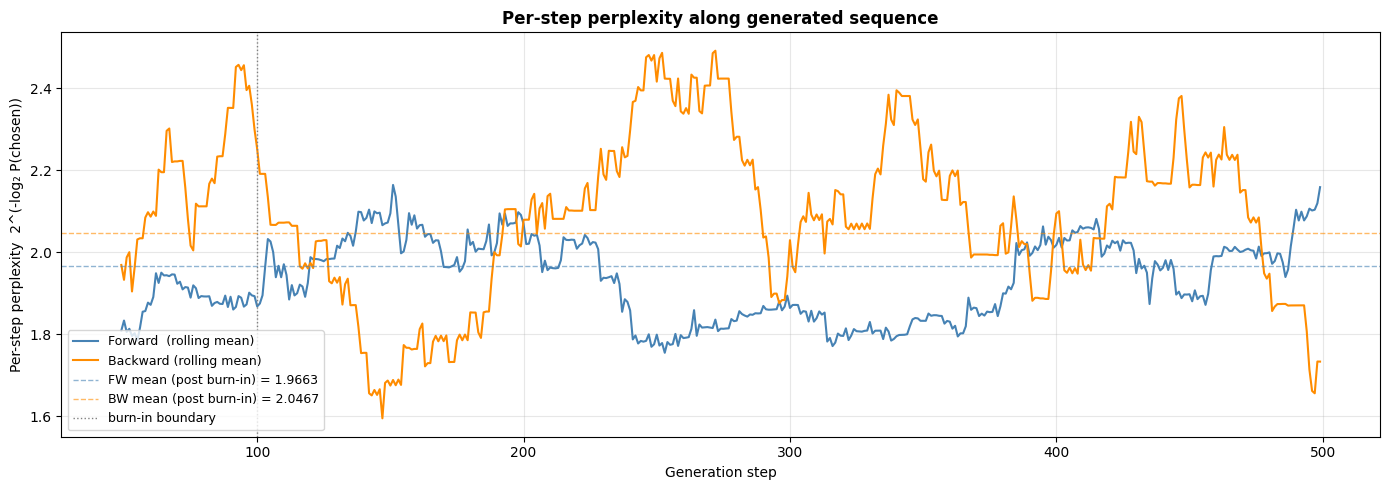


Final PPL estimate  (steps 100–500):
  Forward  PPL = 1.9663
  Backward PPL = 2.0467


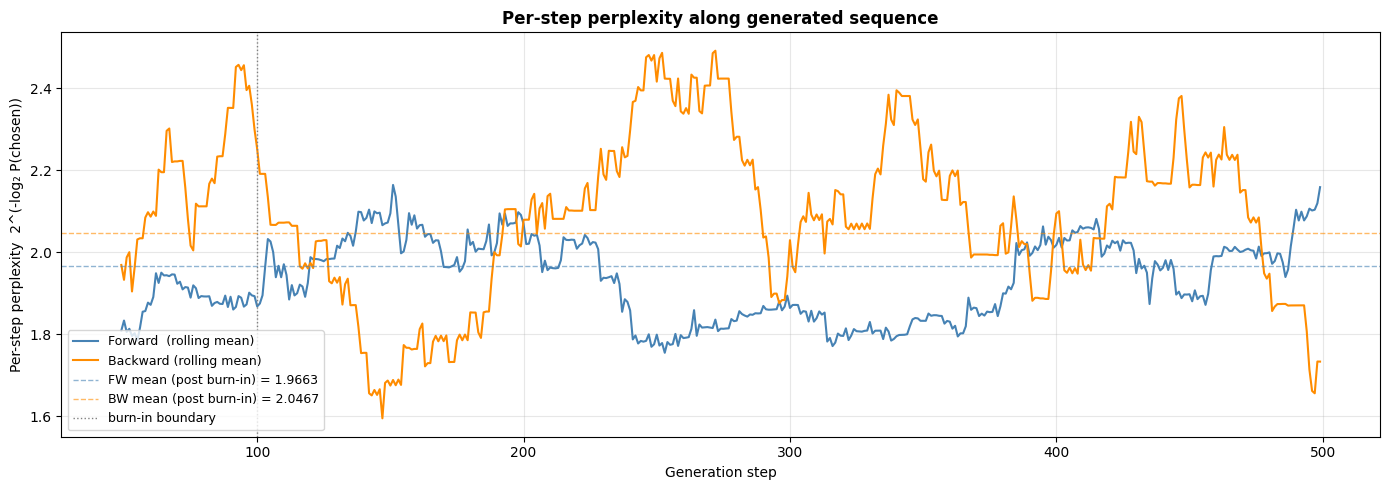

In [34]:
GEN_LEN_PPL = 500
WINDOW      = 50    # rolling window for smoothing

seq_fw, ph_fw, ch_fw = generate_sequence(model_fw, START_TOKEN, GEN_LEN_PPL)
seq_bw, ph_bw, ch_bw = generate_sequence(model_bw, START_TOKEN, GEN_LEN_PPL)

def step_ppl(prob_hist, chosen):
    """Per-step perplexity = 2^(-log2 P(chosen token))"""
    return [2 ** (-np.log2(prob_hist[t][tok] + 1e-12))
            for t, tok in enumerate(chosen)]

ppl_fw = step_ppl(ph_fw, ch_fw)
ppl_bw = step_ppl(ph_bw, ch_bw)

# rolling mean
roll_fw = np.convolve(ppl_fw, np.ones(WINDOW)/WINDOW, mode='valid')
roll_bw = np.convolve(ppl_bw, np.ones(WINDOW)/WINDOW, mode='valid')
steps_r = np.arange(WINDOW - 1, GEN_LEN_PPL)

fig, ax = plt.subplots(figsize=(14, 5))
ax.plot(steps_r, roll_fw, color='steelblue',  lw=1.5, label='Forward  (rolling mean)')
ax.plot(steps_r, roll_bw, color='darkorange', lw=1.5, label='Backward (rolling mean)')

mean_fw = np.mean(ppl_fw[100:])   # after burn-in
mean_bw = np.mean(ppl_bw[100:])
ax.axhline(mean_fw, color='steelblue',  ls='--', lw=1, alpha=0.6,
           label=f'FW mean (post burn-in) = {mean_fw:.4f}')
ax.axhline(mean_bw, color='darkorange', ls='--', lw=1, alpha=0.6,
           label=f'BW mean (post burn-in) = {mean_bw:.4f}')
ax.axvline(100, color='grey', ls=':', lw=1, label='burn-in boundary')

ax.set_xlabel('Generation step')
ax.set_ylabel('Per-step perplexity  2^(-log₂ P(chosen))')
ax.set_title('Per-step perplexity along generated sequence', fontweight='bold')
ax.legend(fontsize=9); ax.grid(True, alpha=0.3)
plt.tight_layout()
display(fig)

print(f'\nFinal PPL estimate  (steps 100–{GEN_LEN_PPL}):')
print(f'  Forward  PPL = {mean_fw:.4f}')
print(f'  Backward PPL = {mean_bw:.4f}')

In [35]:
def cumulative_ppl(prob_hist, chosen):
    """
    Standard perplexity estimated from the beginning up to each step t:

        PPL_t = 2 ^ ( -1/t  Σ_{i=0}^{t}  log2 P(x_i | x_{<i}) )

    This is the standard formula applied to an expanding window [0..t].
    As t → ∞ on a stationary process it converges to 2^H∞.

    Returns
    -------
    ppl_curve : np.ndarray (N,) — one PPL estimate per step
    """
    log2_probs = np.array([
        -np.log2(prob_hist[t][tok] + 1e-12)
        for t, tok in enumerate(chosen)
    ])                                        # (N,) — per-step negative log2 prob

    # cumulative mean up to each t:  (1/t) * Σ_{i=0}^{t} log2_probs[i]
    cumulative_mean = np.cumsum(log2_probs) / np.arange(1, len(log2_probs) + 1)

    return 2 ** cumulative_mean              # (N,) — standard PPL up to step t

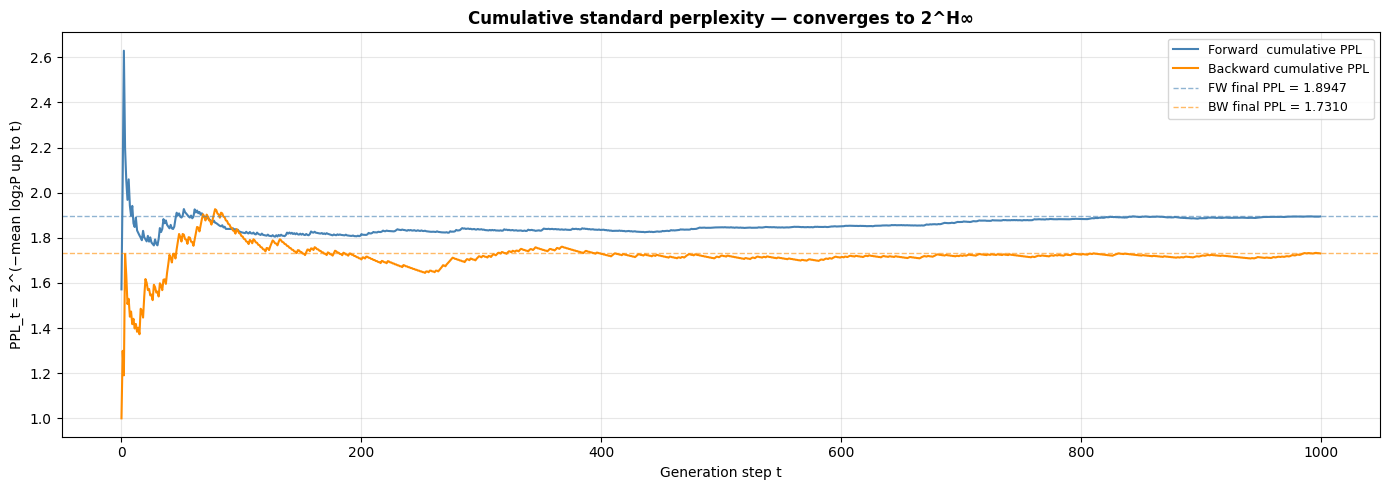


Final standard PPL at step 1000:
  Forward  PPL = 1.8947
  Backward PPL = 1.7310


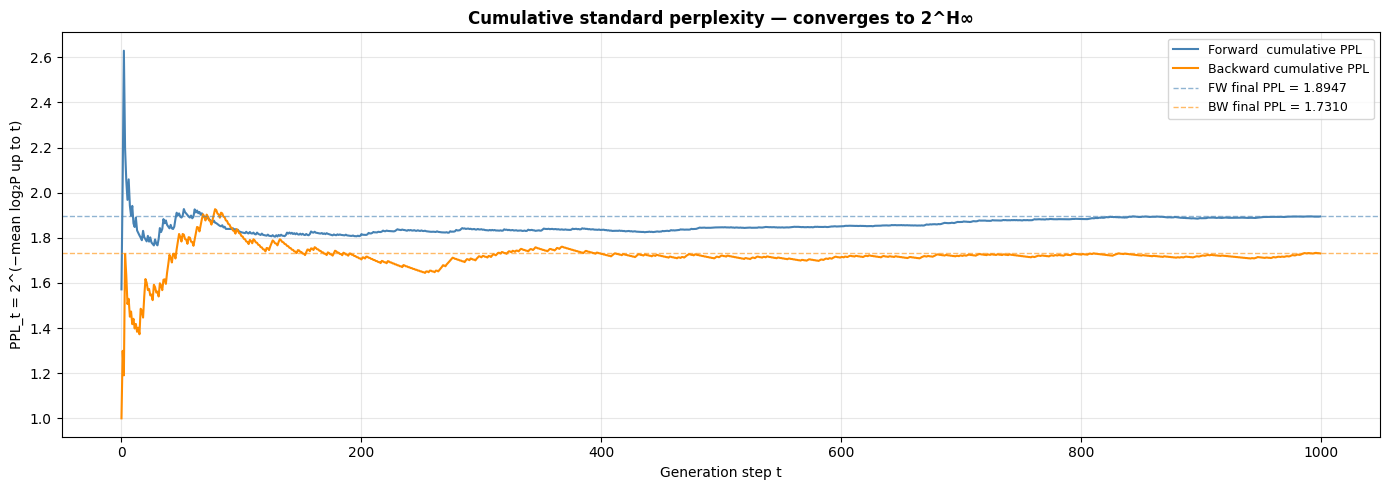

In [36]:
GEN_LEN_PPL = 1000
BURN_IN     = 500

seq_fw, ph_fw, ch_fw = generate_sequence(model_fw, START_TOKEN, GEN_LEN_PPL, burn_in=BURN_IN)
seq_bw, ph_bw, ch_bw = generate_sequence(model_bw, START_TOKEN, GEN_LEN_PPL, burn_in=BURN_IN)

ppl_curve_fw = cumulative_ppl(ph_fw, ch_fw)
ppl_curve_bw = cumulative_ppl(ph_bw, ch_bw)
steps = np.arange(len(ppl_curve_fw))

fig, ax = plt.subplots(figsize=(14, 5))
ax.plot(steps, ppl_curve_fw, color='steelblue',  lw=1.5, label='Forward  cumulative PPL')
ax.plot(steps, ppl_curve_bw, color='darkorange', lw=1.5, label='Backward cumulative PPL')

final_fw = ppl_curve_fw[-1]
final_bw = ppl_curve_bw[-1]
ax.axhline(final_fw, color='steelblue',  ls='--', lw=1, alpha=0.6,
           label=f'FW final PPL = {final_fw:.4f}')
ax.axhline(final_bw, color='darkorange', ls='--', lw=1, alpha=0.6,
           label=f'BW final PPL = {final_bw:.4f}')

ax.set_xlabel('Generation step t')
ax.set_ylabel('PPL_t = 2^(−mean log₂P up to t)')
ax.set_title('Cumulative standard perplexity — converges to 2^H∞', fontweight='bold')
ax.legend(fontsize=9); ax.grid(True, alpha=0.3)
plt.tight_layout()
display(fig)

print(f'\nFinal standard PPL at step {GEN_LEN_PPL}:')
print(f'  Forward  PPL = {final_fw:.4f}')
print(f'  Backward PPL = {final_bw:.4f}')

In [37]:
"""
causal_asymmetry_test.py
========================
Tests causal asymmetry in trained transformer models using the
correct metric: cross-entropy loss on ground-truth sequences.

Metric justification
--------------------
Standard PPL on self-generated sequences only measures self-consistency,
not whether the model's distribution matches the true process.

The correct metric is CE loss on ground-truth sequences:
    L_FW = -1/N * sum_t  log2 P_model(x_t | x_{<t})    (forward model)
    L_BW = -1/N * sum_t  log2 P_model(x_t | x_{>t})    (backward model)

Both evaluated on the SAME ground-truth sequences drawn from the true HMM.
The difference delta_L = L_BW - L_FW is the empirical causal asymmetry.

For the coin process, the true conditional is known analytically so KL
divergence D_KL(P_true || P_model) can also be computed per step,
giving the strongest possible signal.

Theory (Thompson et al. 2017):
    C+ < C-  for the heralding coin process
    -> forward model should achieve lower CE loss at convergence
    -> delta_L > 0  (backward is harder to model)
"""

import os
import gc

import matplotlib
matplotlib.use("Agg")
import matplotlib.pyplot as plt
import numpy as np
import torch

from Data_generation import CoinDataset, coin_generation, flower_process_generation
from Flower_process_generation import FlowerDataset
from OneHot_model import OneHotDecoder
from Training_model import _loader
from Model_analysis import (
    perplexity_calculation,
    statistical_complexity,
    statistical_complexity_empirical,
    savefig,
    mkdir,
)


# ══════════════════════════════════════════════════════════════════════════════
# CONFIG
# ══════════════════════════════════════════════════════════════════════════════
CFG = dict(
    d_model        = 64,
    max_len        = 2000,
    n_layers       = 2,
    num_samples    = 500,
    batch_size     = 32,
    max_batches    = None,        # None = use full dataset
    # coin
    coin_p1        = 0.3,  coin_q1 = 0.4,
    coin_seq_len   = 2000,
    coin_num_token = 3,
    coin_p2        = 0.4,  coin_q2 = 0.8,
    coin_seq_len_12 = 2000,
    # flower
    flower_n       = 6,    flower_m = 4,
    flower_seq_len = 2000,
)

RUN = dict(
    results_dir = "All_Results/results",
    out_dir     = None,
    exp         = "all",    # "all" | "exp1" | "exp1_2" | "exp2"
)


# ══════════════════════════════════════════════════════════════════════════════
# MODEL LOADER
# ══════════════════════════════════════════════════════════════════════════════
def load_model(path, num_token, cfg, mode):
    model = OneHotDecoder(
        token_size=num_token, d_model=cfg["d_model"],
        max_len=cfg["max_len"], mode=mode, n_layers=cfg["n_layers"])
    model.load_state_dict(torch.load(path, map_location="cpu"))
    model.eval()
    print(f"  loaded {path}  [{mode}]")
    return model


# ══════════════════════════════════════════════════════════════════════════════
# METRIC 1 — CE loss on ground-truth sequences
# ══════════════════════════════════════════════════════════════════════════════
def ce_loss_on_truth(model, loader, max_batches=None):
    """
    Cross-entropy loss on ground-truth sequences (bits/token).
    Respects the FW/BW batch convention via perplexity_calculation.

    PPL = 2^CE_loss  so  CE_loss = log2(PPL).

    This is the metric that captures causal asymmetry:
      delta_CE = CE_BW - CE_FW > 0 means backward model needs more bits/token
      which directly mirrors delta_C = C- - C+ from the paper.
    """
    ppl = perplexity_calculation(model, loader, max_batches=max_batches)
    ce  = float(np.log2(ppl))
    return ce, ppl


# ══════════════════════════════════════════════════════════════════════════════
# METRIC 2 — KL divergence from true conditional (coin process only)
# ══════════════════════════════════════════════════════════════════════════════
def coin_true_conditional(last_token, p, q, num_token=3):
    """
    True P(next | last_token) for the coin HMM.

    The causal state after seeing a token depends only on that token:
      token 1  -> state 1  -> P(next) = {1: 1-q,  2: q}
      token 0  -> state 0  -> P(next) = {0: 1-p,  1: p}
      token 2  -> state 0  -> P(next) = {0: 1-p,  1: p}  (same as token 0)
    """
    probs = np.zeros(num_token)
    if last_token == 1:
        probs[1] = 1.0 - q
        probs[2] = q
    else:                   # tokens 0 and 2 both map to causal state 0
        probs[0] = 1.0 - p
        probs[1] = p
    return probs


def kl_from_true_coin(model, loader, p, q, num_token=3, max_batches=None):
    """
    Per-step KL divergence  D_KL( P_true(.|x_t) || P_model(.|x_t) )
    averaged over all positions and sequences.

    A perfectly trained model achieves KL=0.
    The KL gap between BW and FW models measures how much harder the
    backward model finds it to match the true conditional distribution.

    Returns (mean_kl_fw_or_bw, per_token_kl) where per_token_kl is a
    dict mapping each token to its average KL.
    """
    model.eval()
    is_bw  = (getattr(model, "mode", "forward") == "backward")
    device = next(model.parameters()).device

    total_kl    = 0.0
    per_tok_kl  = np.zeros(num_token)
    per_tok_n   = np.zeros(num_token)
    n_steps     = 0

    with torch.no_grad():
        for batch_idx, batch in enumerate(loader):
            if max_batches is not None and batch_idx >= max_batches:
                break
            # mirror training convention
            if is_bw:
                targets, inputs = batch
            else:
                inputs, targets = batch
            inputs = inputs.to(device)
            logits = model(inputs)                          # (B, T, V)
            probs  = torch.softmax(logits, dim=-1).cpu().numpy()

            B, T, _ = probs.shape
            for b in range(B):
                for t in range(T):
                    last_tok = inputs[b, t].item()
                    p_true   = coin_true_conditional(last_tok, p, q, num_token)
                    p_model  = probs[b, t]
                    # KL(P_true || P_model)
                    kl = float(np.sum(
                        p_true * np.log2(p_true / (p_model + 1e-12) + 1e-12)))
                    total_kl           += kl
                    per_tok_kl[last_tok] += kl
                    per_tok_n[last_tok]  += 1
                    n_steps += 1

    mean_kl = total_kl / max(n_steps, 1)
    per_tok  = {
        tok: per_tok_kl[tok] / max(per_tok_n[tok], 1)
        for tok in range(num_token)
    }
    return mean_kl, per_tok


# ══════════════════════════════════════════════════════════════════════════════
# PLOTTING
# ══════════════════════════════════════════════════════════════════════════════
def plot_asymmetry_summary(tag, results, out_dir, h_inf=None):
    """
    4-panel summary figure:
      (a) CE loss FW vs BW + H∞ reference
      (b) delta_CE = CE_BW - CE_FW  (positive = backward harder)
      (c) KL divergence FW vs BW (coin only)
      (d) Statistical complexity FW vs BW
    """
    has_kl = "kl_fw" in results and results["kl_fw"] is not None

    ncols = 4 if has_kl else 3
    fig, axes = plt.subplots(1, ncols, figsize=(5 * ncols, 5))

    colors = {"fw": "#4c72b0", "bw": "#dd8452"}

    # (a) CE loss
    ax = axes[0]
    vals = [results["ce_fw"], results["ce_bw"]]
    bars = ax.bar(["Forward", "Backward"], vals,
                  color=[colors["fw"], colors["bw"]], alpha=0.85, edgecolor="k")
    ax.bar_label(bars, fmt="%.4f", padding=3, fontsize=9)
    if h_inf is not None:
        ax.axhline(h_inf, color="crimson", ls="--", lw=1.5,
                   label=f"H∞ = {h_inf:.4f}")
        ax.legend(fontsize=8)
    ax.set_ylabel("CE loss  (bits/token)")
    ax.set_title("CE loss on ground-truth sequences", fontweight="bold")
    ax.grid(True, alpha=0.3, axis="y")

    # (b) delta_CE
    ax = axes[1]
    delta = results["ce_bw"] - results["ce_fw"]
    color = "#c44e52" if delta > 0 else "#55a868"
    bar = ax.bar(["delta CE  (BW - FW)"], [delta], color=color,
                 alpha=0.85, edgecolor="k")
    ax.bar_label(bar, fmt="%+.4f", padding=3, fontsize=10)
    ax.axhline(0, color="k", ls="--", lw=0.8)
    ax.set_ylabel("bits/token")
    ax.set_title("Causal asymmetry signal\n(+ve = BW harder, aligns with theory)",
                 fontweight="bold")
    ax.grid(True, alpha=0.3, axis="y")

    # (c) KL divergence (coin only)
    if has_kl:
        ax = axes[2]
        kl_vals = [results["kl_fw"], results["kl_bw"]]
        bars = ax.bar(["Forward", "Backward"], kl_vals,
                      color=[colors["fw"], colors["bw"]], alpha=0.85, edgecolor="k")
        ax.bar_label(bars, fmt="%.4f", padding=3, fontsize=9)
        ax.set_ylabel("KL(P_true || P_model)  (bits)")
        ax.set_title("KL from true conditional\n(lower = better fit)", fontweight="bold")
        ax.grid(True, alpha=0.3, axis="y")

    # (d) Statistical complexity
    ax = axes[-1]
    s_emp = [results.get("S_emp_fw", 0), results.get("S_emp_bw", 0)]
    s_th  = [results.get("S_th_fw",  0), results.get("S_th_bw",  0)]
    x = np.arange(2)
    ax.bar(x - 0.2, s_emp, 0.35, label="Empirical",
           color=[colors["fw"], colors["bw"]], alpha=0.85, edgecolor="k")
    ax.bar(x + 0.2, s_th,  0.35, label="Theoretical",
           color=[colors["fw"], colors["bw"]], alpha=0.5,
           edgecolor="k", hatch="//")
    ax.set_xticks(x)
    ax.set_xticklabels(["Forward", "Backward"])
    ax.set_ylabel("Statistical Complexity (bits)")
    ax.set_title("Causal state complexity\n(C- > C+ = asymmetric process)",
                 fontweight="bold")
    ax.legend(fontsize=8)
    ax.grid(True, alpha=0.3, axis="y")

    fig.suptitle(f"{tag} — Causal Asymmetry Test", fontsize=13, fontweight="bold")
    fig.tight_layout()
    savefig(fig, os.path.join(out_dir, f"{tag}_asymmetry.png"))
    print(f"  figure saved -> {out_dir}/{tag}_asymmetry.png")


def plot_per_token_kl(tag, per_tok_kl_fw, per_tok_kl_bw, num_token, out_dir):
    """
    Bar chart of per-token KL divergence.
    Shows which tokens the model struggles with most in each direction.
    """
    x     = np.arange(num_token)
    fig, ax = plt.subplots(figsize=(8, 5))
    ax.bar(x - 0.2,
           [per_tok_kl_fw[i] for i in range(num_token)], 0.35,
           label="Forward",  color="#4c72b0", alpha=0.85, edgecolor="k")
    ax.bar(x + 0.2,
           [per_tok_kl_bw[i] for i in range(num_token)], 0.35,
           label="Backward", color="#dd8452", alpha=0.85, edgecolor="k")
    ax.set_xticks(x)
    ax.set_xticklabels([f"Token {i}" for i in range(num_token)])
    ax.set_ylabel("KL(P_true || P_model)  (bits)")
    ax.set_title(f"{tag} — Per-token KL divergence from true conditional",
                 fontweight="bold")
    ax.legend(fontsize=9)
    ax.grid(True, alpha=0.3, axis="y")
    fig.tight_layout()
    savefig(fig, os.path.join(out_dir, f"{tag}_per_token_kl.png"))


def print_summary(tag, results, h_inf=None):
    sep = "=" * 60
    print(f"\n{sep}")
    print(f"  CAUSAL ASYMMETRY TEST — {tag}")
    print(sep)
    print(f"\n  CE loss on ground-truth sequences (bits/token):")
    print(f"    Forward  CE = {results['ce_fw']:.4f}  "
          f"(PPL = {results['ppl_fw']:.4f})")
    print(f"    Backward CE = {results['ce_bw']:.4f}  "
          f"(PPL = {results['ppl_bw']:.4f})")
    if h_inf:
        print(f"    H∞ (theory) = {h_inf:.4f}")
    delta = results["ce_bw"] - results["ce_fw"]
    sign  = "BW harder (+ve, aligns with theory)" if delta > 0 \
            else "FW harder (-ve, unexpected)"
    print(f"\n  delta_CE = CE_BW - CE_FW = {delta:+.4f}  [{sign}]")

    if results.get("kl_fw") is not None:
        print(f"\n  KL divergence from true conditional:")
        print(f"    Forward  KL = {results['kl_fw']:.4f} bits")
        print(f"    Backward KL = {results['kl_bw']:.4f} bits")
        print(f"    delta_KL    = {results['kl_bw'] - results['kl_fw']:+.4f}")

    print(f"\n  Statistical complexity (empirical / theoretical):")
    print(f"    Forward  C_emp={results.get('S_emp_fw', float('nan')):.4f}  "
          f"C_th={results.get('S_th_fw', float('nan')):.4f}")
    print(f"    Backward C_emp={results.get('S_emp_bw', float('nan')):.4f}  "
          f"C_th={results.get('S_th_bw', float('nan')):.4f}")
    print(sep)


# ══════════════════════════════════════════════════════════════════════════════
# EXPERIMENT RUNNERS
# ══════════════════════════════════════════════════════════════════════════════
def test_coin(tag, p, q, seq_len, models_dir, out_root, cfg):
    odir      = mkdir(os.path.join(out_root, tag))
    num_token = cfg["coin_num_token"]
    print(f"\n{'='*60}\n  TEST — {tag}  p={p}  q={q}\n{'='*60}")

    # ground-truth data
    data, _ = coin_generation(
        num_samples=cfg["num_samples"], seq_len=seq_len, p=p, q=q)
    ds     = CoinDataset(data, seq_len=seq_len)
    loader = _loader(ds, cfg["batch_size"])

    fw_path = os.path.join(models_dir, f"{tag}_fw.pt")
    bw_path = os.path.join(models_dir, f"{tag}_bw.pt")
    if not os.path.exists(fw_path) or not os.path.exists(bw_path):
        print(f"  weights not found — skipping {tag}")
        return

    model_fw = load_model(fw_path, num_token, cfg, mode="forward")
    model_bw = load_model(bw_path, num_token, cfg, mode="backward")

    # ── Metric 1: CE loss on ground-truth ────────────────────────────────────
    ce_fw, ppl_fw = ce_loss_on_truth(model_fw, loader, cfg["max_batches"])
    ce_bw, ppl_bw = ce_loss_on_truth(model_bw, loader, cfg["max_batches"])

    # ── Metric 2: KL from true conditional ───────────────────────────────────
    kl_fw, per_tok_fw = kl_from_true_coin(
        model_fw, loader, p, q, num_token, cfg["max_batches"])
    kl_bw, per_tok_bw = kl_from_true_coin(
        model_bw, loader, p, q, num_token, cfg["max_batches"])

    # ── Metric 3: Statistical complexity ─────────────────────────────────────
    S_emp_fw = statistical_complexity_empirical(
        model_fw, loader, max_batches=cfg["max_batches"], use_t="last", k=2)
    S_emp_bw = statistical_complexity_empirical(
        model_bw, loader, max_batches=cfg["max_batches"], use_t="first", k=3)
    S_th_fw  = statistical_complexity(p, q, mode="forward")
    S_th_bw  = statistical_complexity(p, q, mode="backward")

    # H∞ (entropy rate — symmetric)
    def _h2(a):
        b = max(1-a, 1e-12); a = max(a, 1e-12)
        return -a*np.log2(a) - b*np.log2(b)
    h_inf = (q/(p+q))*_h2(p) + (p/(p+q))*_h2(q)

    results = dict(
        ce_fw=ce_fw, ce_bw=ce_bw, ppl_fw=ppl_fw, ppl_bw=ppl_bw,
        kl_fw=kl_fw, kl_bw=kl_bw,
        S_emp_fw=S_emp_fw, S_emp_bw=S_emp_bw,
        S_th_fw=S_th_fw,   S_th_bw=S_th_bw,
    )

    print_summary(tag, results, h_inf=h_inf)
    plot_asymmetry_summary(tag, results, odir, h_inf=h_inf)
    plot_per_token_kl(tag, per_tok_fw, per_tok_bw, num_token, odir)
    gc.collect()
    return results


def test_flower(tag, n, m, models_dir, out_root, cfg):
    odir      = mkdir(os.path.join(out_root, tag))
    num_token = n + m
    print(f"\n{'='*60}\n  TEST — {tag}  n={n}  m={m}\n{'='*60}")

    rng        = np.random.default_rng(99)
    dice_probs = rng.dirichlet(np.ones(m), size=n)
    data, _ = flower_process_generation(
        num_samples=cfg["num_samples"], seq_len=cfg["flower_seq_len"],
        n=n, m=m, dice_probs=dice_probs)
    ds     = FlowerDataset(data, seq_len=len(data[0]))
    loader = _loader(ds, cfg["batch_size"])

    fw_path = os.path.join(models_dir, f"{tag}_fw.pt")
    bw_path = os.path.join(models_dir, f"{tag}_bw.pt")
    if not os.path.exists(fw_path) or not os.path.exists(bw_path):
        print(f"  weights not found — skipping {tag}")
        return

    model_fw = load_model(fw_path, num_token, cfg, mode="forward")
    model_bw = load_model(bw_path, num_token, cfg, mode="backward")

    ce_fw, ppl_fw = ce_loss_on_truth(model_fw, loader, cfg["max_batches"])
    ce_bw, ppl_bw = ce_loss_on_truth(model_bw, loader, cfg["max_batches"])

    S_emp_fw = statistical_complexity_empirical(
        model_fw, loader, max_batches=cfg["max_batches"], use_t="last",  k=n+1)
    S_emp_bw = statistical_complexity_empirical(
        model_bw, loader, max_batches=cfg["max_batches"], use_t="first", k=m+1)

    results = dict(
        ce_fw=ce_fw, ce_bw=ce_bw, ppl_fw=ppl_fw, ppl_bw=ppl_bw,
        kl_fw=None, kl_bw=None,          # no closed-form for flower
        S_emp_fw=S_emp_fw, S_emp_bw=S_emp_bw,
        S_th_fw=float("nan"), S_th_bw=float("nan"),
    )

    print_summary(tag, results)
    plot_asymmetry_summary(tag, results, odir)
    gc.collect()
    return results


# ══════════════════════════════════════════════════════════════════════════════
# MAIN
# ══════════════════════════════════════════════════════════════════════════════
def main():
    cfg        = CFG.copy()
    models_dir = os.path.join(RUN["results_dir"], "models")
    out_root   = RUN["out_dir"] or os.path.join(RUN["results_dir"], "asymmetry_test")
    mkdir(out_root)
    exp = RUN["exp"].lower()

    if exp in ("all", "exp1"):
        test_coin(
            tag="exp1_coin_p03_q04",
            p=cfg["coin_p1"], q=cfg["coin_q1"],
            seq_len=cfg["coin_seq_len"],
            models_dir=models_dir, out_root=out_root, cfg=cfg)

    if exp in ("all", "exp1_2"):
        test_coin(
            tag="exp1_2_coin_p04_q08",
            p=cfg["coin_p2"], q=cfg["coin_q2"],
            seq_len=cfg["coin_seq_len_12"],
            models_dir=models_dir, out_root=out_root, cfg=cfg)

    if exp in ("all", "exp2"):
        test_flower(
            tag="exp2_flower_n6_m4",
            n=cfg["flower_n"], m=cfg["flower_m"],
            models_dir=models_dir, out_root=out_root, cfg=cfg)

    print(f"\n  DONE — outputs in {out_root}/")


if __name__ == "__main__":
    main()

/Users/tisornnaphattalung/Desktop/Quantum/URECA/.venv_URECA_qt_llm/lib/python3.12/site-packages/umap/umap_.py:2462: UserWarning: n_neighbors is larger than the dataset size; truncating to X.shape[0] - 1
  warn(


umap-learn JIT warm-up succeeded

  TEST — exp1_coin_p03_q04  p=0.3  q=0.4
  loaded results/models/exp1_coin_p03_q04_fw.pt  [forward]
  loaded results/models/exp1_coin_p03_q04_bw.pt  [backward]

  CAUSAL ASYMMETRY TEST — exp1_coin_p03_q04

  CE loss on ground-truth sequences (bits/token):
    Forward  CE = 1.6342  (PPL = 3.1042)
    Backward CE = 2.8496  (PPL = 7.2081)
    H∞ (theory) = 0.9197

  delta_CE = CE_BW - CE_FW = +1.2154  [BW harder (+ve, aligns with theory)]

  KL divergence from true conditional:
    Forward  KL = 0.2150 bits
    Backward KL = 6.7852 bits
    delta_KL    = +6.5702

  Statistical complexity (empirical / theoretical):
    Forward  C_emp=0.9537  C_th=0.9852
    Backward C_emp=1.5467  C_th=1.4888
  figure saved -> results/asymmetry_test/exp1_coin_p03_q04/exp1_coin_p03_q04_asymmetry.png
  figure saved -> results/asymmetry_test/exp1_coin_p03_q04/exp1_coin_p03_q04_asymmetry.png
  figure saved -> results/asymmetry_test/exp1_coin_p03_q04/exp1_coin_p03_q04_per_token_